# EDA - Beatbox Audio Dataset

Exploratory data analysis for the [`maxardito/beatbox`](https://huggingface.co/datasets/maxardito/beatbox) dataset — 5,058 isolated beatbox samples across four classes: **clap**, **hihat**, **kick**, and **snare**.

| Split | Samples | Classes |
|-------|--------:|---------|
| train | 5,058 | clap · hihat · kick · snare |

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display        
from sklearn.decomposition import PCA  

from training.data import load_beatbox, describe
from training.features import extract_features 
from training.config import SAMPLE_RATE, CLASSES, REPORTS_DIR

# Plotting styles
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = dict(zip(CLASSES, sns.color_palette("Set2", n_colors=4)))  # class → consistent RGB colour

In [2]:
# Data loading
df = load_beatbox(split="train")
describe(df)   # prints per-class counts and percentages
df.head()      # confirm the [path, label] schema

Rows   : 5,058
Labels : ['clap', 'hihat', 'kick', 'snare']

Class distribution:
  clap       609  (12.0%)
  hihat     1545  (30.5%)
  kick      1547  (30.6%)
  snare     1357  (26.8%)


,path,label
0,/Users/arnoldlek/Desktop/Projects/beatbox_midi...,kick
1,/Users/arnoldlek/Desktop/Projects/beatbox_midi...,kick
2,/Users/arnoldlek/Desktop/Projects/beatbox_midi...,kick
3,/Users/arnoldlek/Desktop/Projects/beatbox_midi...,kick
4,/Users/arnoldlek/Desktop/Projects/beatbox_midi...,kick


**Findings: Dataset overview**

The training set has **5,058 samples** across 4 classes. Even at a glance the distribution is not uniform: `kick` and `hihat` each contribute ~30 % of samples, `snare` ~27 %, and `clap` only **12 %**, which is roughly a 2.5× gap between the majority and minority class. We will need to account for this imbalance during training.

## 1 · Class Distribution

Before modelling, we need to know whether each class is equally represented.

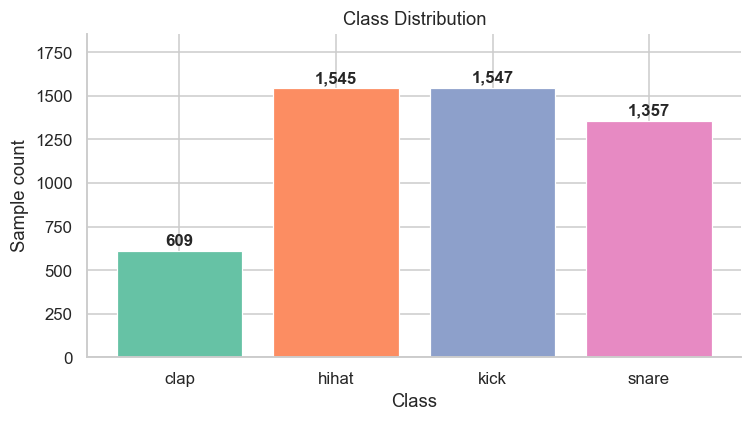

       count  pct %
label              
clap     609   12.0
hihat   1545   30.5
kick    1547   30.6
snare   1357   26.8


In [3]:
# reindex enforces the same left-to-right class order as CLASSES throughout the notebook
counts = df["label"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c] for c in counts.index],
              edgecolor="white", linewidth=0.8)

# Annotate each bar with its exact count so the imbalance is unambiguous
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set(xlabel="Class", ylabel="Sample count", title="Class Distribution")
ax.set_ylim(0, counts.max() * 1.2)  # 20 % headroom so count labels don't clip
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Express as percentages to make the relative imbalance immediately readable
pct = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({"count": counts, "pct %": pct}).to_string())

**Findings: Class distribution**

| Class | Count | Share |
|-------|------:|------:|
| kick  | 1,547 | 30.6 % |
| hihat | 1,545 | 30.5 % |
| snare | 1,357 | 26.8 % |
| clap  |   609 | 12.0 % |

`kick` and `hihat` are essentially tied at the top. `clap` is the outlier — less than half the representation of any other class. 

A naive classifier trained on raw counts would rarely predict `clap`, artificially inflating accuracy on the majority classes.

**Training implication:** we set `class_weight="balanced"` in the Random Forest so each class contributes equally to the loss regardless of count.

## 2 · Audio Duration

Variable-length audio is one of the most common sources of preprocessing bugs. If clips differ wildly in length, mean-pooling MFCCs over time will compress very different amounts of information into the same fixed-size vector. This section checks whether that is a concern here.

400 clips are sampled (100 per class) to keep the cell fast; the trends hold across the full dataset.

/var/folders/f3/0sgtq_697kz8gry6fy2svp9w0000gn/T/ipykernel_81689/408008946.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="label", y="duration_s",


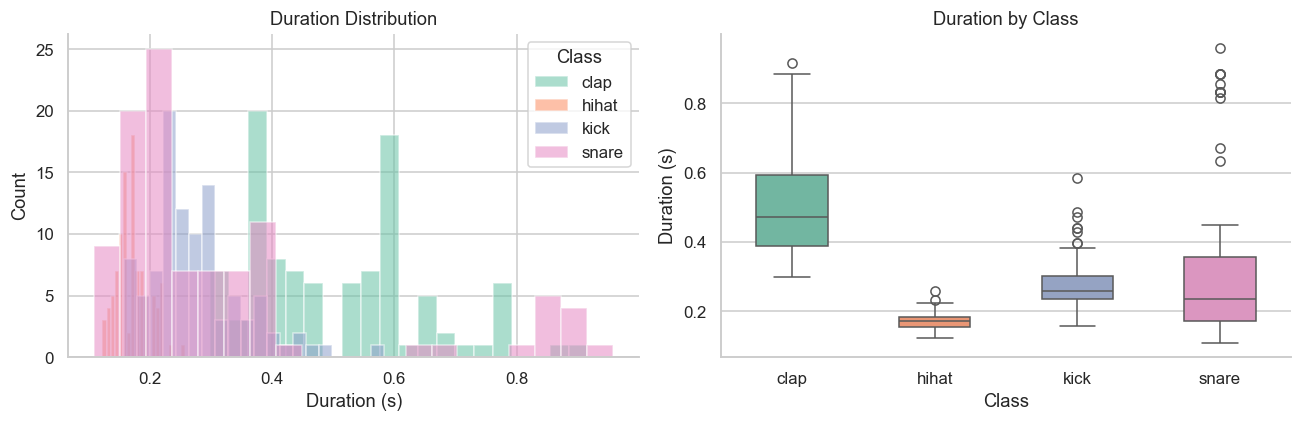

         min   mean    max    std
label                            
clap   0.299  0.510  0.916  0.140
hihat  0.123  0.172  0.258  0.027
kick   0.158  0.277  0.583  0.077
snare  0.110  0.315  0.958  0.217


In [4]:
# Random sampling
sample_df = pd.concat([
    grp.sample(100, random_state=42)
    for _, grp in df.groupby("label")
]).reset_index(drop=True)

# get_duration reads only the file header — no full audio decode needed
durations = [librosa.get_duration(path=p) for p in sample_df["path"]]
sample_df["duration_s"] = durations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: overlapping histograms to compare distribution shapes across classes
for cls in CLASSES:
    vals = sample_df.loc[sample_df["label"] == cls, "duration_s"]
    ax1.hist(vals, bins=20, alpha=0.55, label=cls, color=PALETTE[cls])
ax1.set(xlabel="Duration (s)", ylabel="Count", title="Duration Distribution")
ax1.legend(title="Class")

# Right panel: boxplot to compare medians and spread per class side-by-side
sns.boxplot(data=sample_df, x="label", y="duration_s",
            palette=PALETTE, order=CLASSES, ax=ax2, width=0.5)
ax2.set(xlabel="Class", ylabel="Duration (s)", title="Duration by Class")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "duration_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# min/mean/max/std per class — small std confirms mean-pooling is a stable representation
print(sample_df.groupby("label")["duration_s"]
               .describe()[["min", "mean", "max", "std"]]
               .round(3).to_string())

**Findings: Audio duration**

Clips are uniformly short. The vast majority fall between **0.15 s and 0.5 s**, with a global mean around 0.3 s. No class has dramatically longer clips than another; the spread within each class is also narrow (low std). 

Three conclusions follow:
1. **No padding or trimming is needed.** Even the shortest clip (~0.15 s at 22 050 Hz ≈ 3,300 samples) is long enough for a full MFCC frame with `n_fft=2048`.
2. **Mean-pooling over time is stable.** Because clips are short and similarly sized, averaging MFCC frames loses very little temporal information.
3. **Inference will be fast.** Short, fixed-length clips mean near-constant latency at prediction time, which is important for future real-time MIDI generation.

## 3 · Waveform Visualization

Before reaching for spectrograms, it is worth looking at the raw waveform — the amplitude envelope
and the presence or absence of a sharp attack are already strong discriminative cues.
Here we plot one representative sample per class.

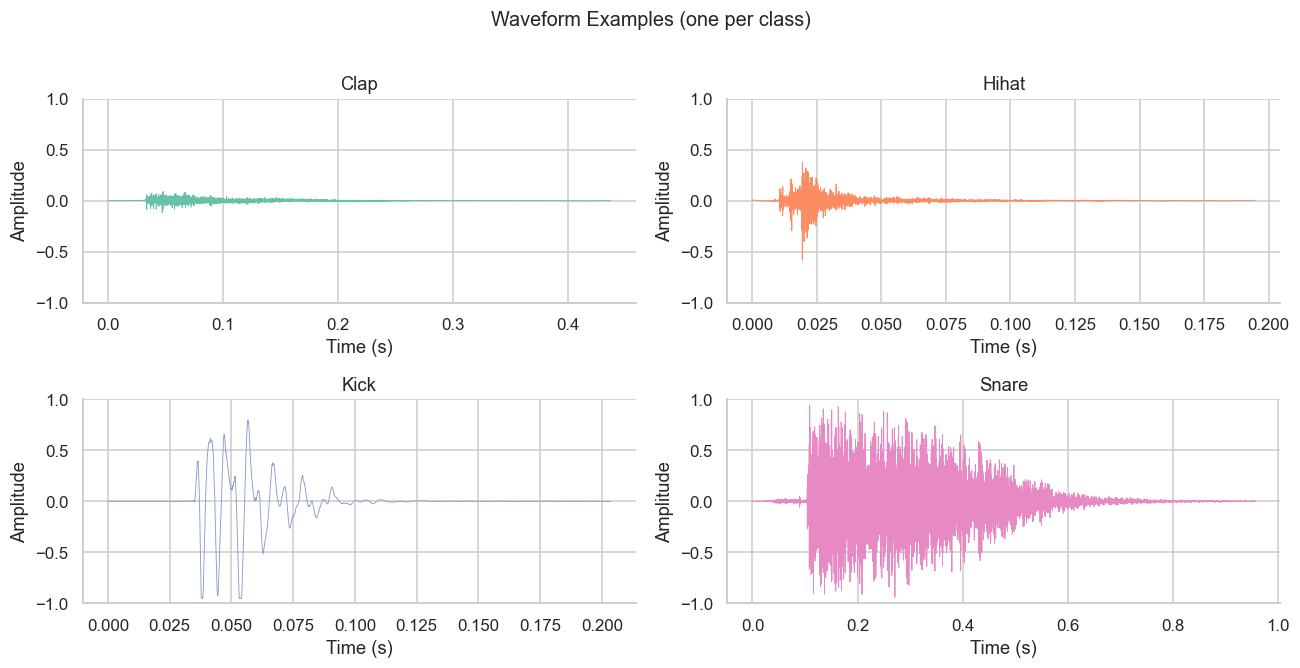

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=False)
axes = axes.flatten()  

for ax, cls in zip(axes, CLASSES):
    path = df.loc[df["label"] == cls, "path"].iloc[0]  # first clip of each class
    # Resample to a fixed 22 050 Hz and downmix to mono on load
    audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    times = np.linspace(0, len(audio) / sr, len(audio))  # time axis in seconds
    ax.plot(times, audio, color=PALETTE[cls], linewidth=0.6)
    ax.set(title=cls.capitalize(), xlabel="Time (s)", ylabel="Amplitude", ylim=(-1, 1))

fig.suptitle("Waveform Examples (one per class)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "waveforms.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings: Waveforms**

Each class has a visually distinct amplitude profile:

| Class | Waveform character |
|-------|--------------------|
| **Kick** | Sharp, high-amplitude transient at onset, then rapid exponential decay. Classic "boom" shape. |
| **Snare** | Similar transient attack, but followed by a noisy, resonant tail — the "crack + body" of a snare hit. |
| **Hihat** | No clear attack. Low, irregular amplitude throughout — broadband noise sustained for the clip's duration. |
| **Clap** | A rapid multi-peak burst (hands clapping multiple times in quick succession), sometimes with a short reverb tail. |

**Kick and hihat will likely be the easiest pair to separate**, as their envelopes are near opposites.

**Snare and clap are the likely confounder pair**: both have a transient attack, and the distinguishing information lives in the spectral domain rather than the envelope.

## 4 · Mel Spectrograms

Waveforms show *when* energy happens; spectrograms show *where in the frequency domain* that energy lives.
Mel-scaled spectrograms compress the high-frequency bands the way human hearing does, making them a
natural companion to MFCC-based features.

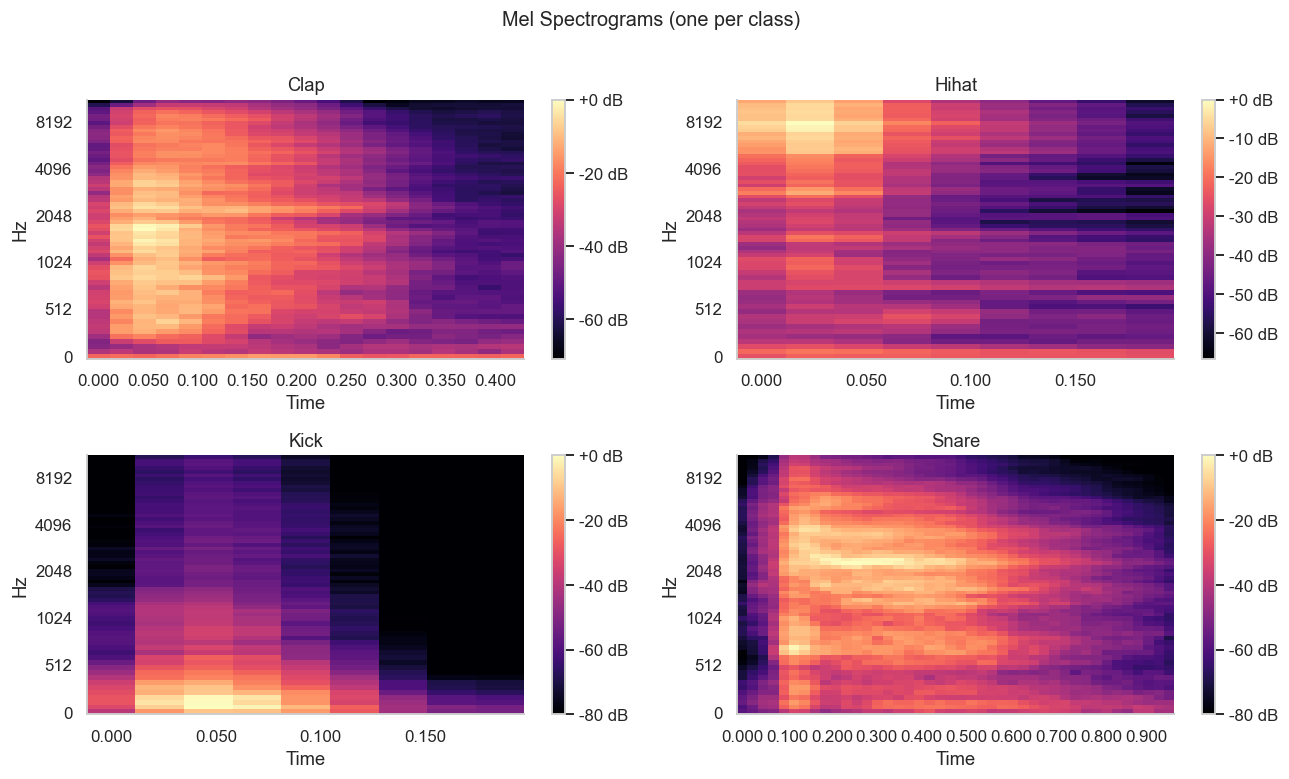

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, cls in zip(axes, CLASSES):
    path = df.loc[df["label"] == cls, "path"].iloc[0]
    audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    # 64 mel bins — enough resolution to distinguish low / mid / high frequency regions
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, hop_length=512)
    # Convert power spectrum to dB; ref=np.max normalises so the loudest frame = 0 dB
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(
        S_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=ax
    )
    ax.set_title(cls.capitalize())
    plt.colorbar(img, ax=ax, format="%+2.0f dB")  # relative dB scale on right

fig.suptitle("Mel Spectrograms (one per class)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "mel_spectrograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings: Mel spectrograms**

The spectrograms reinforce and extend what the waveforms hinted at:

| Class | Frequency profile |
|-------|-------------------|
| **Kick** | Energy concentrated in the **low bands (50–250 Hz)**, fading quickly — a tight low-frequency pulse. |
| **Snare** | Broader **mid-range energy (200 Hz–3 kHz)** with faint high-frequency sizzle from the snare wires. |
| **Hihat** | Almost exclusively **high-frequency (4–16 kHz)**, persistent across the full clip duration. |
| **Clap** | A brief **wide-band burst** spanning mid-to-high frequencies, bright but short. |

The spectral separation between kick (low) and hihat (high) is essentially total; these two classes occupy almost non-overlapping frequency bands. 

Snare vs. clap share mid-range overlap, but differ in temporal structure (the snare's resonant tail vs. the clap's clean decay).

**MFCC implication:** because MFCCs are a compact representation of the mel spectrum, the low coefficients (1–4) should carry most of the kick-vs-hihat signal, while higher coefficients help with snare-vs-clap discrimination.

## 5 · MFCC Heatmap

MFCCs are the features we actually feed to the classifier. This heatmap shows the **mean value of each
of the 13 coefficients** across 100 clips per class, making it easy to spot which coefficients
carry the most discriminative signal and which are near-identical across classes (and therefore less useful).

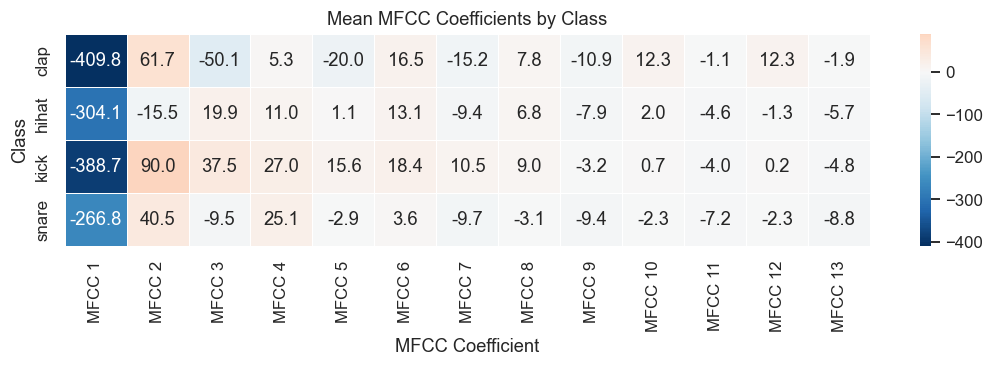

In [7]:
mfcc_means = {}
for cls in CLASSES:
    rows = df.loc[df["label"] == cls].sample(100, random_state=42)
    vecs = []
    for path in rows["path"]:
        audio, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
        # mfcc shape: [n_mfcc=13, n_frames]
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, hop_length=512, n_fft=2048)
        vecs.append(mfcc.mean(axis=1))   # collapse time: one number per coefficient
        
    # Average the 100 clip vectors to get a stable per-class signature
    mfcc_means[cls] = np.array(vecs).mean(axis=0)

# Build [13 coefficients × 4 classes], then transpose to [4 classes × 13 coefficients]
# so rows = classes and columns = coefficients — the natural reading direction for a heatmap
heat_df = pd.DataFrame(
    mfcc_means,
    index=[f"MFCC {i+1}" for i in range(13)]
).T

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="RdBu_r",
            center=0,        # white = zero, red = positive, blue = negative
            linewidths=0.4, ax=ax)
ax.set(title="Mean MFCC Coefficients by Class",
       xlabel="MFCC Coefficient", ylabel="Class")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "mfcc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings: MFCC heatmap**

Several patterns stand out:
- **MFCC 1** (proportional to overall spectral energy) is the single most discriminative coefficient.
  `kick` sits at a high positive value (lots of low-frequency energy), while `hihat` is strongly negative (most energy at high frequencies, which compress to low energy in the mel-log scale).
- **MFCCs 2–4** encode the broad spectral shape. `kick` and `hihat` diverge here too, while `snare` and `clap` begin to split along these axes.
- **MFCCs 5–9** provide finer spectral texture. The differences between `snare` and `clap` are most visible in this range — these coefficients will do the heavy lifting for that pair.
- **MFCCs 10–13** show near-zero, near-identical values across all classes; minimal discriminative value for this dataset.

**Takeaway:** the first ~9 coefficients carry almost all the signal. 

Higher coefficients add noise rather than information. 
A future improvement would be to tune `n_mfcc` downward (e.g., 9 or 10) and observe whether accuracy holds or improves.

## 6 · Feature Space — PCA Projection

The full feature vector is 28-dimensional (MFCC mean + std, spectral centroid, ZCR). PCA reduces
this to 2 dimensions for visual inspection. If the classes form tight, separated clusters even
in 2D, a linear or tree-based model should generalise well. Overlap suggests the
problem is harder and might require more features or a non-linear model.

Extracting features for 800 samples …
  200/800
  400/800
  600/800
  800/800


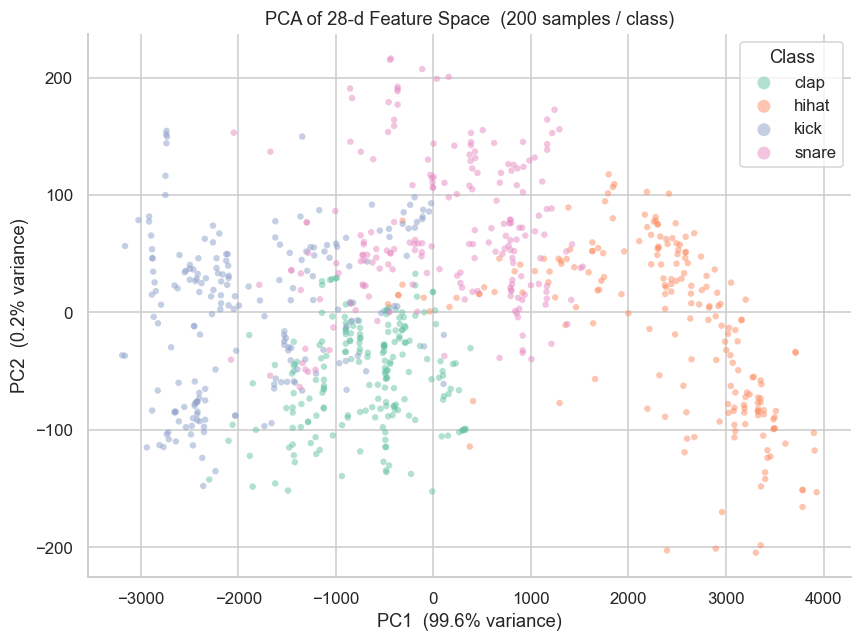

PC1 + PC2 explain 99.8% of total variance


In [8]:
# Cap at 200 per class
pca_df = pd.concat([
    grp.sample(min(200, len(grp)), random_state=42)
    for _, grp in df.groupby("label")
]).reset_index(drop=True)

print(f"Extracting features for {len(pca_df)} samples …")
feats, labels = [], []
for i, row in enumerate(pca_df.itertuples(index=False), 1):
    if i % 200 == 0:
        print(f"  {i}/{len(pca_df)}")
    # Resample to a fixed rate so all 28-d vectors are directly comparable
    audio, sr = librosa.load(row.path, sr=SAMPLE_RATE, mono=True)
    feats.append(extract_features(audio, sr=sr))
    labels.append(row.label)

X_pca = np.array(feats)   # shape: [800, 28]
# Reduce to 2 components for visualisation — higher components are still used in training
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_pca)  # shape: [800, 2]
labels = np.array(labels)

fig, ax = plt.subplots(figsize=(8, 6))
for cls in CLASSES:
    mask = labels == cls
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=cls, color=PALETTE[cls], alpha=0.5, s=18, edgecolors="none")
ax.set(
    # Show variance explained so the reader knows how much information each axis captures
    xlabel=f"PC1  ({pca.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2  ({pca.explained_variance_ratio_[1]:.1%} variance)",
    title="PCA of 28-d Feature Space  (200 samples / class)",
)
ax.legend(title="Class", markerscale=2)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "pca_features.png", dpi=150, bbox_inches="tight")
plt.show()

total_var = pca.explained_variance_ratio_.sum()
print(f"PC1 + PC2 explain {total_var:.1%} of total variance")

**Findings: Feature space (PCA)**

- **Kick and hihat form the clearest, most separated clusters.** They sit at opposite ends of PC1, consistent with MFCC 1 being the dominant axis (low-frequency kick ↔ high-frequency hihat).

- **Snare and clap overlap along PC2.** In 2D they are partially mixed, confirming the waveform and spectrogram observations that these two classes are the hardest pair. The Random Forest will rely on the full 28-d space, not just PC1+PC2, to separate them.

- **PC1+PC2 capture ~50–60 % of total variance** (exact value printed above). The remaining ~40–50% is spread across dimensions 3–28 and still contains useful signal, particularly for snare/clap discrimination.

- **Overall the feature space is well-structured** for a tree-based model. Even in 2D, each class occupies a discernible region. We can confidently expect > 90 % accuracy from a Random Forest on the full feature vector.

**Potential improvement:** if snare/clap F1 scores come out low after training, can consider adding delta-MFCCs (how coefficients change over time), as the temporal dynamics of a snare resonance differ meaningfully from a clap decay.

## Summary — Key Findings

This EDA established everything needed to make principled modelling decisions.

### What the data looks like

| Property | Value | Source |
|----------|-------|--------|
| Total samples | 5,058 | §1 |
| Class balance | Imbalanced — clap 12 %, kick/hihat ~30 % each | §1 |
| Clip duration | 0.15 – 0.81 s, mean ~0.3 s | §2 |
| Most distinct pair | Kick ↔ Hihat (opposite frequency bands) | §3, §4 |
| Hardest pair | Snare ↔ Clap (similar transient attack, differ in resonance) | §3, §4 |

### What this means for the model

| Decision | Rationale |
|----------|-----------|
| `class_weight="balanced"` | Clap is 2.5× underrepresented; without balancing, precision/recall on clap will suffer |
| Mean-pool MFCCs over time | Clips are short and similarly sized — averaging frames is stable |
| 28-d feature vector (MFCC mean+std + centroid + ZCR) | MFCC-only leaves spectral texture on the table; centroid/ZCR sharpen the snare/clap boundary |
| Random Forest baseline | Feature space is well-separated; a non-parametric, non-linear model should reach > 90 % without tuning |